# Bayesian Classifier
In this lab, you will implement and assess the performance of the Bayesian Classifier.

## Lab Instructions:
1. Read the explanation above each requirement very well
2. Read the requirement very well before jumping into the code.
3. Some requirements have essay questions in them, make sure you do NOT miss them.
4. PLEASE Read the hints! They are clear and made to help you complete the requirement as fast as you should 

In [1]:
#### always keep all your imports in the first cell ####
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import csv
import math

%matplotlib inline

## Requirement

In this requirement, you will build the Bayesian Classifier and test its performance. 

You are provided with a data file **data1.csv** containing list of points and their corresponding classes. The format of the data files is shown in the table below.

| |Class|Feature 1|Feature 1| 
|-|-|-|-|
|Point#1|1|0.271633|-2.93224|
|Point#2|1|7.020786|-1.98966|
|Point#3|1|2.901827|-0.91291|


You are also provided with a test data file **test_data.csv**. The file contains test points that are unlabelled (i.e. the class to which they belong is unknown).

In [2]:
# TODO [1] : Read the file 'data1.csv' into the variable data.
# data contains the training data together with labelled classes.
def read_data(file_name):
    ## HINT 1: How is the data ordered in the file?
    ## HINT 2: Do you need to cast the data you read from the file?
    data = []
    with open(file_name, 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            # Each row: [class, feature1, feature2]
            # "do you need to cast?" — yes, because csv.reader gives strings, but we need numbers.
            data.append([float(val) for val in row])
    return np.array(data)

In [3]:
def read_test_data():
    
    # TODO [2.A]: Read the file 'test_data.csv' into the variable test_data
    # test_data contains the unlabelled test class.
    ## HINT: Do you need to cast the data you read from the file?

    test_data = []
    with open('test_data.csv', 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            test_data.append([float(val) for val in row])
    test_data = np.array(test_data)
    
    
    # TODO [2.B]: Read the file 'test_data_true.csv' into the variable test_data_true
    # test_data_true contains the actual classes of the test instances, which you will compare
    # against your predicted classes.
    ## HINT: Do you need to cast the data you read from the file?

    test_data_true = []
    with open('test_data_true.csv', 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            test_data_true.append([float(val) for val in row])
    test_data_true = np.array(test_data_true)
    
    return test_data, test_data_true

### Machine Learning Terminlology
Machine learning problems use common termonology (names and notiations) to refer to certain things. It is useful to use this termonology throughout your code to make it readable.

| | |
|:-|:--- |
|$M$:|A scalar; represents the number of training points in the training set.|
|$K$:|A scalar; represents the number of test points in the test set.|
|$N$:|A scalar; represents the number of features of training set/test set (dimensionality of data).|
|$X$:|A numpy array of shape $(M \times N)$ containing the training data **without** its labels, where $M$ is the number of training points and $N$ is the number of features in the dataset (or dimensionality of features). <br/> Each element in $X$ is a tuple $(X_1, X_2, \dots, X_N)$ where $N$ is the number of features in the dataset.| 
|$X_{test}$:| A numpy array of shape $(K \times N)$ containing the test data, where $K$ is the number of test points and $N$ is the number of features in the dataset (or dimensionality of features). <br/> Each element in $X_{test}$ is a tuple $(X_1, X_2, \dots, X_N)$ where $N$ is the number of features in the dataset. <br/> The number of columns in $X_{test}$ is equal to the number of columns in $X$ (because they have the same number of features). However, the number of rows in $X_{test}$ is different to the number of rows in $X$.|
|**$Y$:| A numpy array of shape $(M \times 1)$ containing the labels of the training data. Each row in $Y$ corresponds to the label of the training point in $X$.<br/> For example, $Y[j]$ corresponds to the label of the training point $X[j]$ where $0<=j<M$.|



In [4]:
# TODO [3]: Fill the values of M, K, N, X, XTest, and Y respectively.
# Do not fill them manually (i.e. do not set N = 3). They should be generic for any input file.  
training_data = read_data('data1.csv')
test_data, test_data_true = read_test_data()

numClasses = 3 
# M: number of training points
M = training_data.shape[0]

# N: number of features (columns minus the class column)
N = training_data.shape[1] - 1

# K: number of test points
K = test_data.shape[0]

# X: training features (all columns except the first which is the class)
X = training_data[:, 1:]

# X_Test: test features
X_Test = test_data

# Y: training labels (first column)
Y = training_data[:, 0]

print(f'M (training points) = {M}')
print(f'N (features)        = {N}')
print(f'K (test points)     = {K}')
print(f'X shape             = {X.shape}')
print(f'X_Test shape        = {X_Test.shape}')
print(f'Y shape             = {Y.shape}')

M (training points) = 1150
N (features)        = 2
K (test points)     = 450
X shape             = (1150, 2)
X_Test shape        = (450, 2)
Y shape             = (1150,)


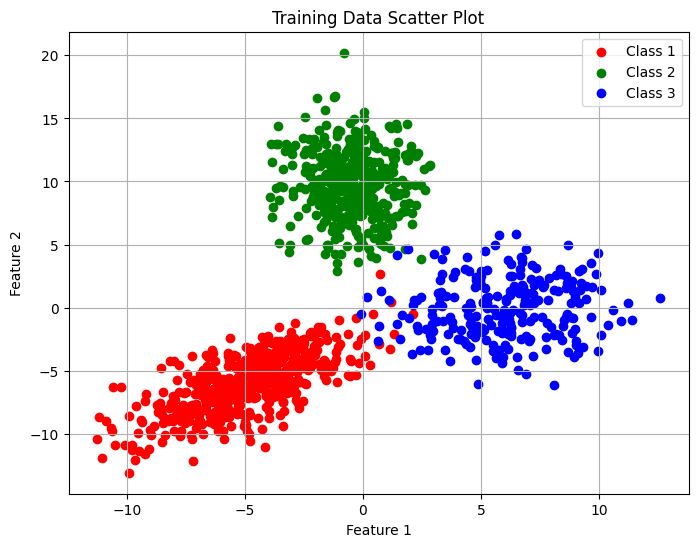

In [5]:
# TODO [4]: Draw a scatter plot for traning data, where each class is coloured by the colour corresponding 
#           to its index in the colors array.
# Class 1 should be coloured in red, Class 2 should be coloured in green, and Class 3 should be coloured in blue.
# Hint: We have done a similar plot in the previous lab. What operation do we need to select training data 
#       belonging to a certain class?

colors = ['r', 'g', 'b', 'c', 'y']
plt.figure(figsize=(8, 6))
for classIndex in range(numClasses):
    # Select training points belonging to class (classIndex + 1) since classes are 1-indexed
    class_points = X[Y == (classIndex + 1)]
    plt.scatter(class_points[:, 0], class_points[:, 1],
                c=colors[classIndex],
                label=f'Class {classIndex + 1}')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data Scatter Plot')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
## What do you notice about the plot? (Write everything you can think of)
'''
    Your Answer:
    1. The three classes form distinct clusters, each roughly centered around a different region in 2D feature space.
    2. Each cluster appears roughly elliptical, suggesting the data within each class follows an approximately
       Gaussian (normal) distribution — which makes Bayesian classification with a Gaussian assumption appropriate.
    3. There is some overlap between the clusters near their boundaries, meaning a small classification
       error near those decision boundaries is expected.
    4. The classes are not linearly separable, so a simple linear classifier would struggle, but a
       Bayesian classifier that models the full covariance structure should perform well.
    5. The clusters appear to have different covariance structures (shapes and orientations),
       which means using a full covariance matrix per class (QDA-style) is better than a shared one.
''' 

'\n    Your Answer:\n    1. The three classes form distinct clusters, each roughly centered around a different region in 2D feature space.\n    2. Each cluster appears roughly elliptical, suggesting the data within each class follows an approximately\n       Gaussian (normal) distribution — which makes Bayesian classification with a Gaussian assumption appropriate.\n    3. There is some overlap between the clusters near their boundaries, meaning a small classification\n       error near those decision boundaries is expected.\n    4. The classes are not linearly separable, so a simple linear classifier would struggle, but a\n       Bayesian classifier that models the full covariance structure should perform well.\n    5. The clusters appear to have different covariance structures (shapes and orientations),\n       which means using a full covariance matrix per class (QDA-style) is better than a shared one.\n'

### Bayesian Classifier
The Bayesian Classifier calculates the probability of the test point belonging to each class, then the class with highest probability is assigned to the test point.

Classification of $x_{test}$ = $argmax_{i} P\big(C_i|x_{test}\big)$ = $argmax_{i} P(x|C_i) * P(C_i)$

* $P(C_i|x_{test})$: Posterior probability
* $P(x|C_i)$: Class-conditional probability (or distribution)
* $P(C_i)$: Class apriori probability
                
**Note that** $P(C_i|x_{test}) \neq P(x_{test}|C_i) * P(C_i)$. Instead,  $P(C_i|x_{test}) = \frac{P(x_{test}|C_i) * P(C_i)}{P(x_{test})}$. However, when we compare multiple classes, the denominator $P(x_{test})$ is independent of the class $i$ and can be regarded as normalizing factor.

**We start by** computing statistical parameters about each class from the data. 

For each class, we are interested in **three** parameters that will be used for calculating the Gaussian class-conditional distribution and the posterior probability.

These parameters are:

|||
|:-|:-|
|**Class Apriori Probability: ($P_C$)**| A scalar; the probability of class occurence (how frequent this class appears in the training data)|
|**Class Mean: ($\mu$)**| A vector of shape $(N \times 1)$, it is the expected value (mean) calculated from the training points of each class.|
|**Class Covariance Matrix: ($\Sigma$)**| A square symmetric matrix of shape $(N \times N)$ representing the covariances between all the feature calculated from the training points of the class. <br/> For example: Matrix element $\sigma^2_{12}$ is the covariance between the 1st and the 2nd features|



In [7]:
pClasses = [] # A list of size (numClasses, 1) containing the a priori probabilities of each class in the training set.

estimate_means = [] # A numpy array of size (numClasses, N) containing the mean points of each class in the training set. 
                    # HINT: USE NP.MEAN

estimate_covariances = [] # A numpy array of size (numClasses, N, N) containing the covariance matrices of each class in the training set.
                          # HINT: USE NP.COV (Pay attenention for what it takes as an argument)
                             
for classIndex in range(numClasses):
    # TODO [5]: Estimate the parameters of the Gaussian distributions of the given classes.
    # Fill pClasses, estimate_means, and estimate_covariances in this part 
    # Your code should be vectorized WITHOUT USING A SINGLE FOR LOOP.
    # Select all training points belonging to this class (classes are 1-indexed)
    class_points = X[Y == (classIndex + 1)]
    
    # A priori probability: fraction of training points belonging to this class
    # Inside the loop, for the last class:
    if classIndex < numClasses - 1:
        pClasses.append(class_points.shape[0] / M)
    else:
        pClasses.append(1.0 - sum(pClasses))  # ensures exact sum of 1
    
    # Class mean: mean of each feature across all points of this class
    # np.mean with axis=0 gives a vector of shape (N,)
    estimate_means.append(np.mean(class_points, axis=0))
    
    # Class covariance: np.cov expects features as rows, so we transpose
    # class_points is (M_c x N), transposing gives (N x M_c)
    estimate_covariances.append(np.cov(class_points.T))

estimate_means = np.array(estimate_means)
estimate_covariances = np.array(estimate_covariances)

print('pClasses:', pClasses)
print('estimate_means shape:', estimate_means.shape)
print('estimate_covariances shape:', estimate_covariances.shape)

pClasses: [0.43478260869565216, 0.34782608695652173, 0.21739130434782616]
estimate_means shape: (3, 2)
estimate_covariances shape: (3, 2, 2)


In [8]:
### Test your implementation ###
### DO NOT CHANGE THIS CODE ###
assert len(pClasses) == numClasses,\
        'Incorrect class apriori probability list, it should be of length {}'.format(len(pClasses))
assert np.sum(pClasses)==1,\
        'Sum of apriori probabilities should be 1, found {}'.format(np.sum(pClasses))

assert estimate_means.shape == (numClasses, N),\
        'Incorrect estimated means, it should be of shape {}'.format((numClasses, N))
assert estimate_covariances.shape == (numClasses, N, N),\
        'Incorrect estimate covariance matrices, it should be of shape {}'.format((numClasses, N, N))

**The second step** in the classifier is to calculate the class-conditional density using the Gaussian destribution:

$P(x|C_i) = \mathcal{N}(x; \mu_i, \Sigma_i) = \frac{1}{(2\pi)^{\frac{N}{2}}|\Sigma_i|^{\frac{1}{2}}} exp\big(\frac{-1}{2}(x-\mu_i)^T\Sigma^{-1}_{i}(x-\mu_i)\big)$

In [9]:
# TODO 6: Implement the multivariate normal gaussian distribution with parameters mu and sigma, and return the
#  value in prob.
def multivariate_normal_gaussian(X, mu, sigma):
    """
    Computes the multivariate Gaussian probability density.
    
    Parameters:
        X     : feature vector, shape (N, 1)
        mu    : mean vector, shape (N, 1)
        sigma : covariance matrix, shape (N, N)
    
    Returns:
        prob  : scalar probability density value
    """
    N = X.shape[0]  # number of features / dimensionality
    
    # Difference between point and mean
    diff = X - mu  # shape (N, 1)
    
    # Determinant of covariance matrix
    det_sigma = np.linalg.det(sigma)
    
    # Inverse of covariance matrix
    inv_sigma = np.linalg.inv(sigma)
    
    # Normalization factor: 1 / ((2*pi)^(N/2) * |sigma|^(1/2))
    norm_factor = 1.0 / ((2 * np.pi) ** (N / 2) * np.sqrt(det_sigma))
    
    # Exponent: -0.5 * (x - mu)^T * sigma^-1 * (x - mu)
    exponent = -0.5 * (diff.T @ inv_sigma @ diff)
    
    prob = norm_factor * np.exp(exponent)
    return prob

In [10]:
### Test your implementation ###
### DO NOT CHANGE THIS CODE ###
np.random.seed(90)
assertion_x = np.random.rand(3).reshape(-1,1)
assertion_mu = np.random.rand(3).reshape(-1,1)
assertion_sigma = np.random.rand(9).reshape(3,3)
assertion_probability = multivariate_normal_gaussian(assertion_x, assertion_mu, assertion_sigma)[0][0]
assertion_probability = round(assertion_probability, 1)

assert assertion_probability == 7.8,\
    'Incorrect Gaussian Probability calculated'

**The final step** is to go for each test point, calculate its posterior probability against each class, then classify it to the class with the highest posterior probability.

In [11]:
# TODO [7]: Apply the Bayesian Classifier to predict the classes of the test points.
predicted_classes = [] # predicted_classes: A numpy array of size (K, 1) where K is the number of points in the test set. Every element in this array
                       # contains the predicted class of Bayes classifier for this test point.

for i in range(X_Test.shape[0]):
    print("For test point:", X_Test[i])
    classProbabilities = np.zeros(numClasses)
    
    # TODO [7.A]: Compute the probability that the test point X_Test[i] belongs to each class in numClasses.
    #  Fill the array classProbabilities accordingly.
    for classIndex in range(numClasses):
        # Reshape test point to column vector (N, 1)
        x = X_Test[i].reshape(-1, 1)
        
        # Class mean as column vector (N, 1)
        mu = estimate_means[classIndex].reshape(-1, 1)
        
        # Class covariance matrix
        sigma = estimate_covariances[classIndex]
        
        # Posterior ∝ P(x | C_i) * P(C_i)
        likelihood = multivariate_normal_gaussian(x, mu, sigma)[0][0]
        classProbabilities[classIndex] = likelihood * pClasses[classIndex]
    
    # TODO [7.B]: Find the prediction of the test point X_Test[i] and append it to the predicted_classes array.
    # Classes are 1-indexed, so add 1 to the argmax index
    predicted_class = np.argmax(classProbabilities) + 1
    predicted_classes.append(predicted_class)

    print('Class Probabilities: ', classProbabilities)  # the first class is the left most in the scatter plot
    print("Predicted class is :", predicted_classes[i])
    print("******************************************************************************")

predicted_classes = np.array(predicted_classes)


For test point: [10.70141426  3.87253627]
Class Probabilities:  [2.65667378e-12 2.14599814e-17 2.49128533e-04]
Predicted class is : 3
******************************************************************************
For test point: [-3.81831787 -5.00977814]
Class Probabilities:  [1.54057607e-02 1.59733837e-10 1.94606997e-07]
Predicted class is : 1
******************************************************************************
For test point: [-3.57071936  9.96036181]
Class Probabilities:  [7.93462259e-20 1.36556777e-03 5.38717673e-11]
Predicted class is : 2
******************************************************************************
For test point: [ 4.94309043 -0.01539406]
Class Probabilities:  [1.95768749e-06 1.94246409e-08 5.69470433e-03]
Predicted class is : 3
******************************************************************************
For test point: [ 4.26082551 -0.61349358]
Class Probabilities:  [6.24062368e-06 4.98423484e-08 4.72790312e-03]
Predicted class is : 3
**************

In [12]:
# TODO [8]: Compute the accuracy of the generated Bayesian classifier 
# WITHOUT USING ANY FOR LOOPs.
# Accuracy = fraction of correctly predicted classes (vectorized, no for loops)
# Flatten test_data_true to a 1D array for comparison
true_classes = test_data_true.flatten()
accuracy = np.sum(predicted_classes == true_classes) / K
print('Accuracy = ' + str(round(accuracy,4) * 100) + '%')

Accuracy = 95.56%


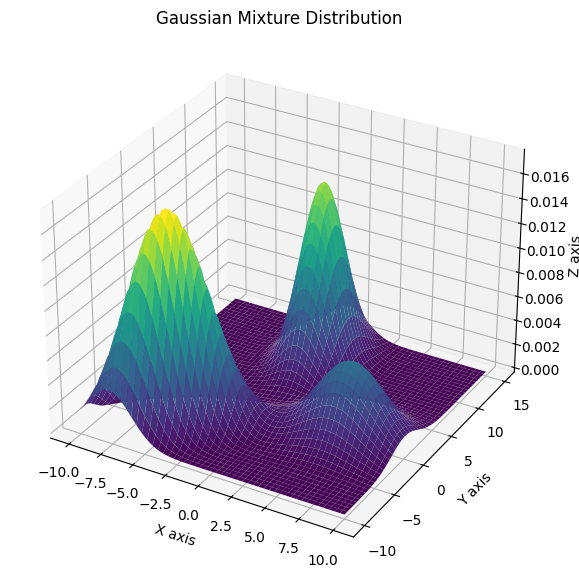

In [13]:
# TODO [9]: Generate a 3D-plot for the generated distributions. x-axis and y-axis represent the features of the data, 
#           where z-axis represent the Gaussian probability N at this point.

x = np.linspace(-10, 10, 300)
y = np.linspace(-10, 15, 300)
X_grid, Y_grid = np.meshgrid(x, y)
Z = np.zeros(X_grid.shape)

for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        # TODO [9]: Fill in the matrix Z which will represent the probability distribution of every point.
        # Z[i,j] represents the joint probability N(x,y) for x = i and y = j. 
        # We want to draw the gaussian probability N(x,y) for all points. 
        # We sum the weighted Gaussian of each class (mixture model visualization)
        point = np.array([[X_grid[i, j]], [Y_grid[i, j]]])
        total_prob = 0
        for classIndex in range(numClasses):
            mu = estimate_means[classIndex].reshape(-1, 1)
            sigma = estimate_covariances[classIndex]
            total_prob += pClasses[classIndex] * multivariate_normal_gaussian(point, mu, sigma)[0][0]
        Z[i, j] = total_prob

# Make a 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_grid, Y_grid, Z, cmap='viridis', linewidth=0)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('Gaussian Mixture Distribution')
plt.show()

In [14]:
# How can you judge your plot is correct?
'''
    Your Answer:
    We can judge the correctness of the 3D plot by checking the following:
    
    1. Number of peaks: The plot should show exactly 3 distinct peaks (one per class),
       each located near the mean of its respective class cluster seen in the 2D scatter plot.
    
    2. Peak positions: Each peak's (x, y) location should correspond to the estimated mean
       (estimate_means[classIndex]) of the corresponding class.
    
    3. Peak heights and widths: The height and spread of each peak should reflect the
       covariance structure of its class. A class with a small, tight covariance will produce
       a tall, narrow peak, while a large covariance produces a shorter, wider peak.
    
    4. The surface should integrate to approximately 1 (since it is a probability distribution).
'''

"\n    Your Answer:\n    We can judge the correctness of the 3D plot by checking the following:\n    \n    1. Number of peaks: The plot should show exactly 3 distinct peaks (one per class),\n       each located near the mean of its respective class cluster seen in the 2D scatter plot.\n    \n    2. Peak positions: Each peak's (x, y) location should correspond to the estimated mean\n       (estimate_means[classIndex]) of the corresponding class.\n    \n    3. Peak heights and widths: The height and spread of each peak should reflect the\n       covariance structure of its class. A class with a small, tight covariance will produce\n       a tall, narrow peak, while a large covariance produces a shorter, wider peak.\n    \n    4. The surface should integrate to approximately 1 (since it is a probability distribution).\n"